In [ ]:
import os, zipfile, shutil, random
from tqdm.notebook import tqdm
import time

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
GOOD_ZIP = "/content/drive/MyDrive/RoadDamageBD/Good_Roads.zip"
BAD_ZIP  = "/content/drive/MyDrive/RoadDamageBD/Damaged_Roads.zip"

RAW_DIR = "/content/raw"
SPLIT_DIR = "/content/split"
TRAIN_DIR = f"{SPLIT_DIR}/train"
VAL_DIR   = f"{SPLIT_DIR}/val"
TEST_DIR  = f"{SPLIT_DIR}/test"

for d in [RAW_DIR, SPLIT_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)

for d in [RAW_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(d, exist_ok=True)

In [ ]:
def extract_zip(zip_path, class_name):
    dest = os.path.join(RAW_DIR, class_name)
    os.makedirs(dest, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(dest)
    print(class_name, "images:", len(os.listdir(dest)))

extract_zip(GOOD_ZIP, "Good_Roads")
extract_zip(BAD_ZIP, "Damaged_Roads")

Good_Roads images: 125
Damaged_Roads images: 325


In [ ]:
random.seed(42)

for cls in os.listdir(RAW_DIR):
    imgs = os.listdir(f"{RAW_DIR}/{cls}")
    random.shuffle(imgs)

    n = len(imgs)
    train = imgs[:int(0.7*n)]
    val   = imgs[int(0.7*n):int(0.85*n)]
    test  = imgs[int(0.85*n):]

    for split, data in zip([TRAIN_DIR, VAL_DIR, TEST_DIR], [train, val, test]):
        os.makedirs(f"{split}/{cls}", exist_ok=True)
        for img in data:
            shutil.copy(f"{RAW_DIR}/{cls}/{img}", f"{split}/{cls}/{img}")

    print(cls, f"train={len(train)} val={len(val)} test={len(test)}")

Damaged_Roads train=227 val=49 test=49
Good_Roads train=87 val=19 test=19


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR, eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

Using device: cpu
Classes: ['Damaged_Roads', 'Good_Roads']


In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        return self.fc(self.features(x).flatten(1))

In [ ]:
def train_model_verbose(model, model_name):
    model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    criterion = nn.CrossEntropyLoss()

    train_acc, val_acc = [], []
    train_loss, val_loss = [], []

    start_time = time.time()   # ⏱ start timer

    for epoch in range(1, EPOCHS + 1):
        print(f"\n[{model_name}] Epoch {epoch}/{EPOCHS}")

        # -------- TRAIN --------
        model.train()
        correct = total = loss_sum = 0

        for x, y in tqdm(train_loader, desc="Training"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_acc.append(correct / total)
        train_loss.append(loss_sum / len(train_loader))

        # -------- VALIDATION --------
        model.eval()
        correct = total = loss_sum = 0
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc="Validating"):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)

                loss_sum += loss.item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_acc.append(correct / total)
        val_loss.append(loss_sum / len(val_loader))

        print(f"Train Acc={train_acc[-1]:.3f} | Val Acc={val_acc[-1]:.3f}")

    total_time = time.time() - start_time
    print(f"[{model_name}] Training Time: {total_time:.2f} sec")

    return train_acc, val_acc, train_loss, val_loss, total_time

In [ ]:
# 1. Custom CNN
custom_model = CustomCNN(num_classes)
c_tr_acc, c_va_acc, c_tr_loss, c_va_loss, c_time = train_model_verbose(
    custom_model, "Custom CNN"
)

# 2. ResNet Scratch
res_s = models.resnet18(weights=None)
res_s.fc = nn.Linear(res_s.fc.in_features, num_classes)
rs_tr_acc, rs_va_acc, rs_tr_loss, rs_va_loss, rs_time = train_model_verbose(
    res_s, "ResNet Scratch"
)

# 3. VGG Scratch
vgg_s = models.vgg16(weights=None)
vgg_s.classifier[6] = nn.Linear(4096, num_classes)
vs_tr_acc, vs_va_acc, vs_tr_loss, vs_va_loss, vs_time = train_model_verbose(
    vgg_s, "VGG Scratch"
)

# 4. ResNet Transfer Learning
res_t = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in res_t.parameters():
    p.requires_grad = False
res_t.fc = nn.Linear(res_t.fc.in_features, num_classes)

r_tr_acc, r_va_acc, r_tr_loss, r_va_loss, r_time = train_model_verbose(
    res_t, "ResNet Transfer"
)

# 5. VGG Transfer Learning
vgg_t = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
for p in vgg_t.features.parameters():
    p.requires_grad = False
vgg_t.classifier[6] = nn.Linear(4096, num_classes)

v_tr_acc, v_va_acc, v_tr_loss, v_va_loss, v_time = train_model_verbose(
    vgg_t, "VGG Transfer"
)


[Custom CNN] Epoch 1/5


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validating:   0%|          | 0/3 [00:00<?, ?it/s]

Train Acc=0.659 | Val Acc=0.721

[Custom CNN] Epoch 2/5


Training:   0%|          | 0/10 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/3 [00:00<?, ?it/s]

Train Acc=0.946 | Val Acc=0.956

[VGG Transfer] Epoch 5/5


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validating:   0%|          | 0/3 [00:00<?, ?it/s]

Train Acc=0.968 | Val Acc=0.882
[VGG Transfer] Training Time: 1232.80 sec


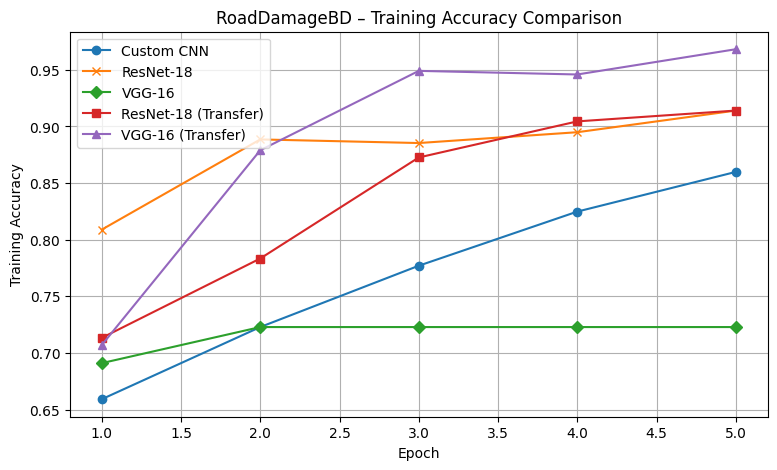

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(9,5))

plt.plot(epochs, c_tr_acc, marker="o", label="Custom CNN")

plt.plot(epochs, rs_tr_acc, marker="x", label="ResNet-18")
plt.plot(epochs, vs_tr_acc, marker="D", label="VGG-16")

plt.plot(epochs, r_tr_acc, marker="s", label="ResNet-18 (Transfer)")
plt.plot(epochs, v_tr_acc, marker="^", label="VGG-16 (Transfer)")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("RoadDamageBD – Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

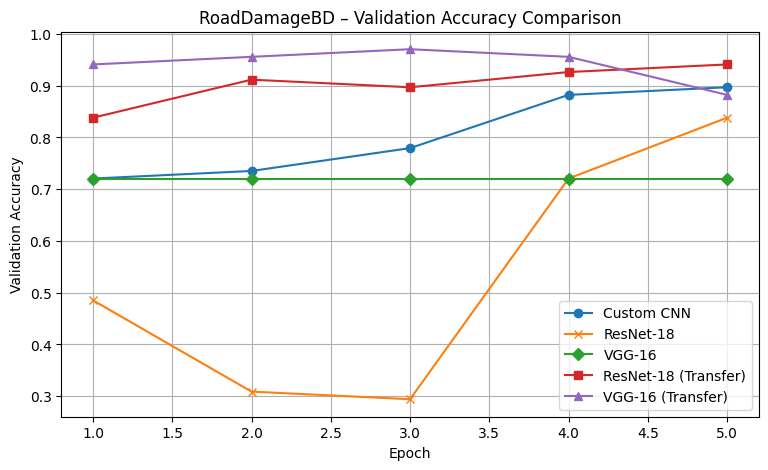

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(9,5))

plt.plot(epochs, c_va_acc, marker="o", label="Custom CNN")

plt.plot(epochs, rs_va_acc, marker="x", label="ResNet-18")
plt.plot(epochs, vs_va_acc, marker="D", label="VGG-16")

plt.plot(epochs, r_va_acc, marker="s", label="ResNet-18 (Transfer)")
plt.plot(epochs, v_va_acc, marker="^", label="VGG-16 (Transfer)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("RoadDamageBD – Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

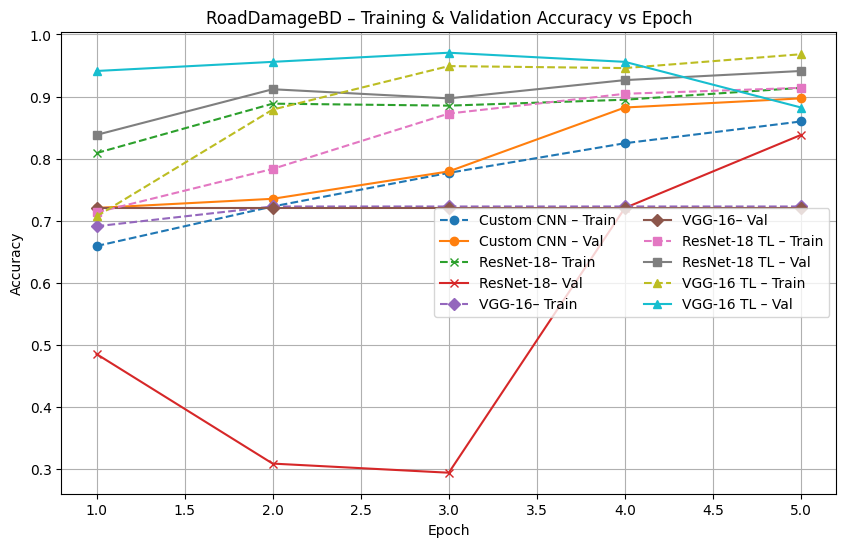

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10,6))

# -------- Custom CNN --------
plt.plot(epochs, c_tr_acc, '--o', label="Custom CNN – Train")
plt.plot(epochs, c_va_acc, '-o',  label="Custom CNN – Val")

# -------- ResNet-18 Scratch --------
plt.plot(epochs, rs_tr_acc, '--x', label="ResNet-18– Train")
plt.plot(epochs, rs_va_acc, '-x',  label="ResNet-18– Val")

# -------- VGG-16 Scratch --------
plt.plot(epochs, vs_tr_acc, '--D', label="VGG-16– Train")
plt.plot(epochs, vs_va_acc, '-D',  label="VGG-16– Val")

# -------- ResNet-18 Transfer --------
plt.plot(epochs, r_tr_acc, '--s', label="ResNet-18 TL – Train")
plt.plot(epochs, r_va_acc, '-s',  label="ResNet-18 TL – Val")

# -------- VGG-16 Transfer --------
plt.plot(epochs, v_tr_acc, '--^', label="VGG-16 TL – Train")
plt.plot(epochs, v_va_acc, '-^',  label="VGG-16 TL – Val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RoadDamageBD – Training & Validation Accuracy vs Epoch")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

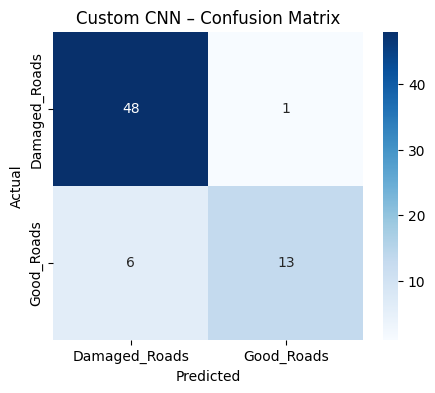

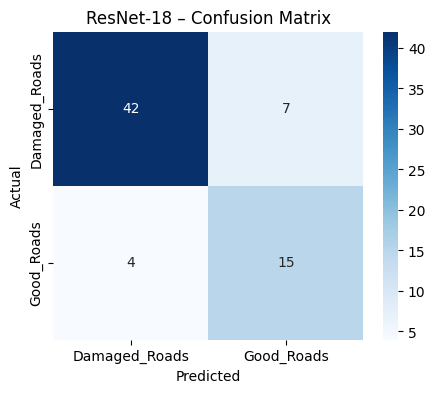

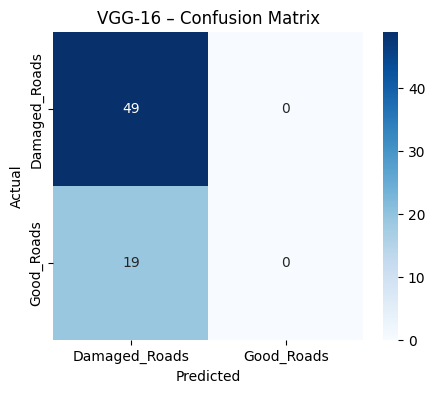

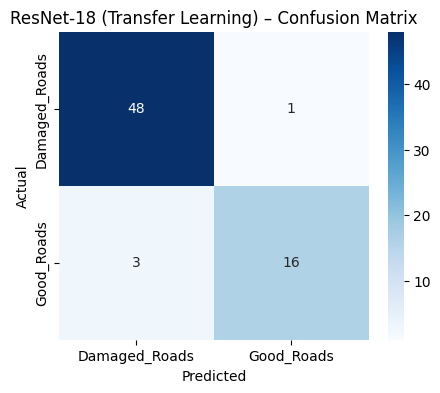

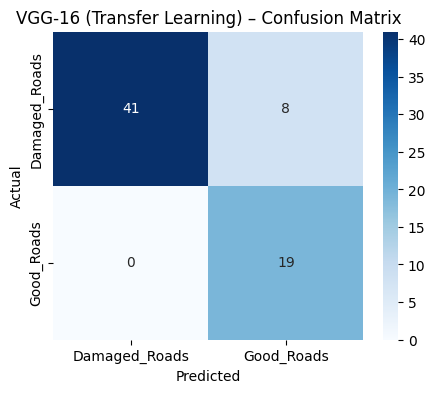

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_preds(model):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            out = model(x.to(device))
            y_true.extend(y.cpu().numpy())
            y_pred.extend(out.argmax(1).cpu().numpy())
    return y_true, y_pred

y_c, p_c = get_preds(custom_model)

plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_c, p_c),
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Custom CNN – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

y_rs, p_rs = get_preds(res_s)

plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_rs, p_rs),
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("ResNet-18 – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

y_vs, p_vs = get_preds(vgg_s)

plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_vs, p_vs),
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("VGG-16 – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

y_rt, p_rt = get_preds(res_t)

plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_rt, p_rt),
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("ResNet-18 (Transfer Learning) – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

y_vt, p_vt = get_preds(vgg_t)

plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_vt, p_vt),
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("VGG-16 (Transfer Learning) – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return acc, pr, rc, f1
# Custom CNN
yc, pc = get_preds(custom_model)

# ResNet Scratch
yrs, prs = get_preds(res_s)

# VGG Scratch
yvs, pvs = get_preds(vgg_s)

# ResNet Transfer
yrt, prt = get_preds(res_t)

# VGG Transfer
yvt, pvt = get_preds(vgg_t)
df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet-18 (Scratch)",
        "VGG-16 (Scratch)",
        "ResNet-18 (Transfer)",
        "VGG-16 (Transfer)"
    ],

    "Accuracy": [
        compute_metrics(yc, pc)[0],
        compute_metrics(yrs, prs)[0],
        compute_metrics(yvs, pvs)[0],
        compute_metrics(yrt, prt)[0],
        compute_metrics(yvt, pvt)[0]
    ],

    "Precision": [
        compute_metrics(yc, pc)[1],
        compute_metrics(yrs, prs)[1],
        compute_metrics(yvs, pvs)[1],
        compute_metrics(yrt, prt)[1],
        compute_metrics(yvt, pvt)[1]
    ],

    "Recall": [
        compute_metrics(yc, pc)[2],
        compute_metrics(yrs, prs)[2],
        compute_metrics(yvs, pvs)[2],
        compute_metrics(yrt, prt)[2],
        compute_metrics(yvt, pvt)[2]
    ],

    "F1-Score": [
        compute_metrics(yc, pc)[3],
        compute_metrics(yrs, prs)[3],
        compute_metrics(yvs, pvs)[3],
        compute_metrics(yrt, prt)[3],
        compute_metrics(yvt, pvt)[3]
    ],

    "Training Time (seconds)": [
        c_time,
        rs_time,
        vs_time,
        r_time,
        v_time
    ]
}).round(4)

df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (seconds)
0,Custom CNN,0.8971,0.9000,0.8971,0.8918,426.3954
1,ResNet-18 (Scratch),0.8382,0.8484,0.8382,0.8416,552.6473
2,VGG-16 (Scratch),0.7206,0.5192,0.7206,0.6036,2716.2594
3,ResNet-18 (Transfer),0.9412,0.9412,0.9412,0.9401,378.8047
4,VGG-16 (Transfer),0.8824,0.9172,0.8824,0.8874,1232.8005
